In [4]:
DM, boxsize, res = '', 205, 1250

data_path = '/n/holylfs05/LABS/hernquist_lab/IllustrisTNG/Runs/'
basePath = data_path + 'L%dn%dTNG/output'%(boxsize,res)

root_dir = '/n/home01/sqyu/AstroLab/TNG/'
load_dir = f'{root_dir}/result/DMhalo_mass_table/sim_{boxsize}_{res}{DM}/'

In [5]:
import pandas as pd
mass_df      = pd.read_csv(load_dir+'mass_table.csv', index_col=0)
accretion_df = pd.read_csv(load_dir+'accretion_table.csv', index_col=0)

In [6]:
mass_df      = mass_df.loc[['snap_8', 'snap_13', 'snap_25', 'snap_40', 'snap_67', 'snap_99']]
accretion_df = accretion_df.loc[['snap_8', 'snap_13', 'snap_25', 'snap_40', 'snap_67', 'snap_99']]

In [7]:
snap_list = mass_df.index
print(snap_list)

Index(['snap_8', 'snap_13', 'snap_25', 'snap_40', 'snap_67', 'snap_99'], dtype='object')


In [11]:
import numpy as np

mass_cuts = np.arange(1, 4.5, 0.5)
num_cuts  = int((4.5-1)/0.5)

median_array = np.zeros((len(snap_list), len(mass_cuts)-1))
std_array    = np.zeros((len(snap_list), len(mass_cuts)-1))
lowp_array   = np.zeros((len(snap_list), len(mass_cuts)-1))
highp_array  = np.zeros((len(snap_list), len(mass_cuts)-1))

print(median_array)

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


In [10]:
from matplotlib import pyplot as plt 
plt.style.use(f'{root_dir}/code/style.mplstyle')

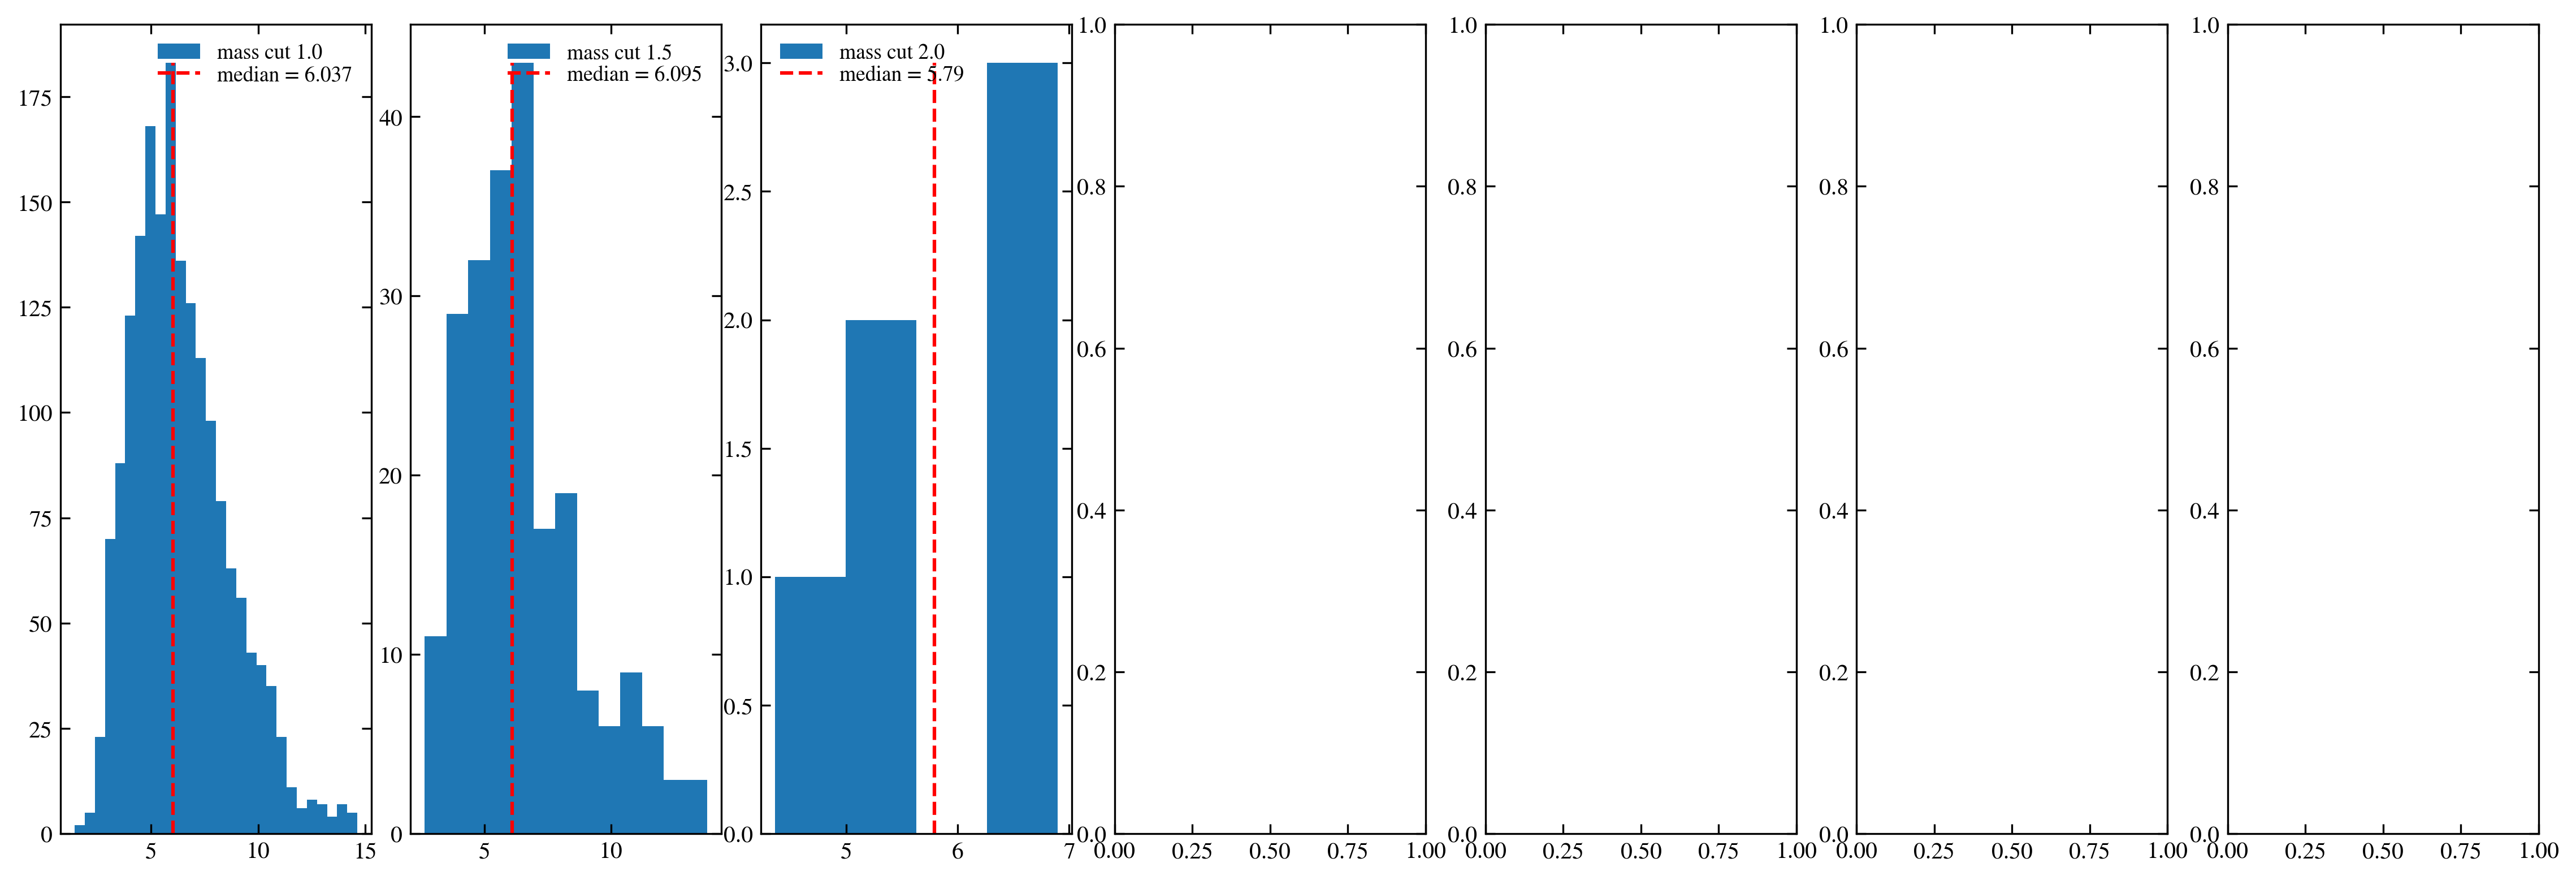

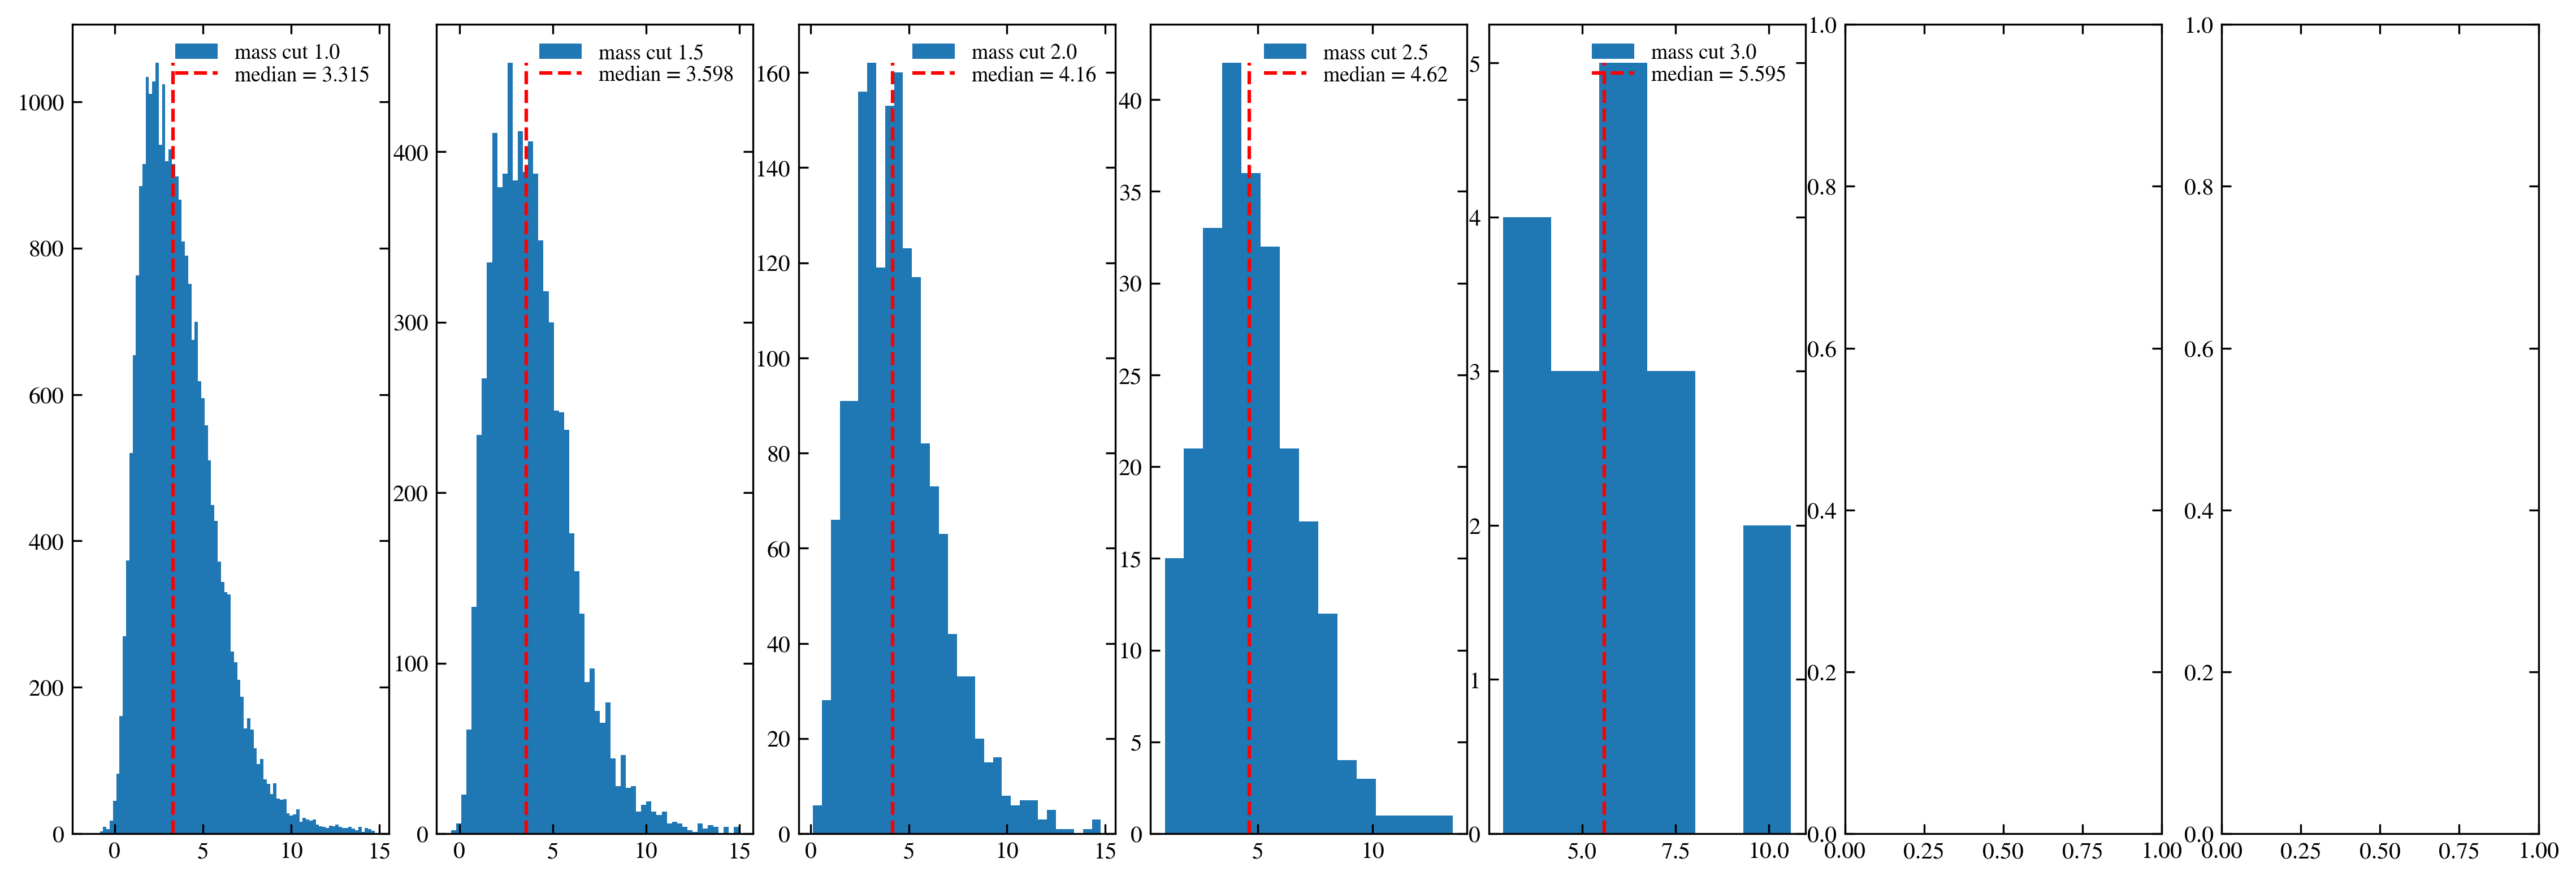

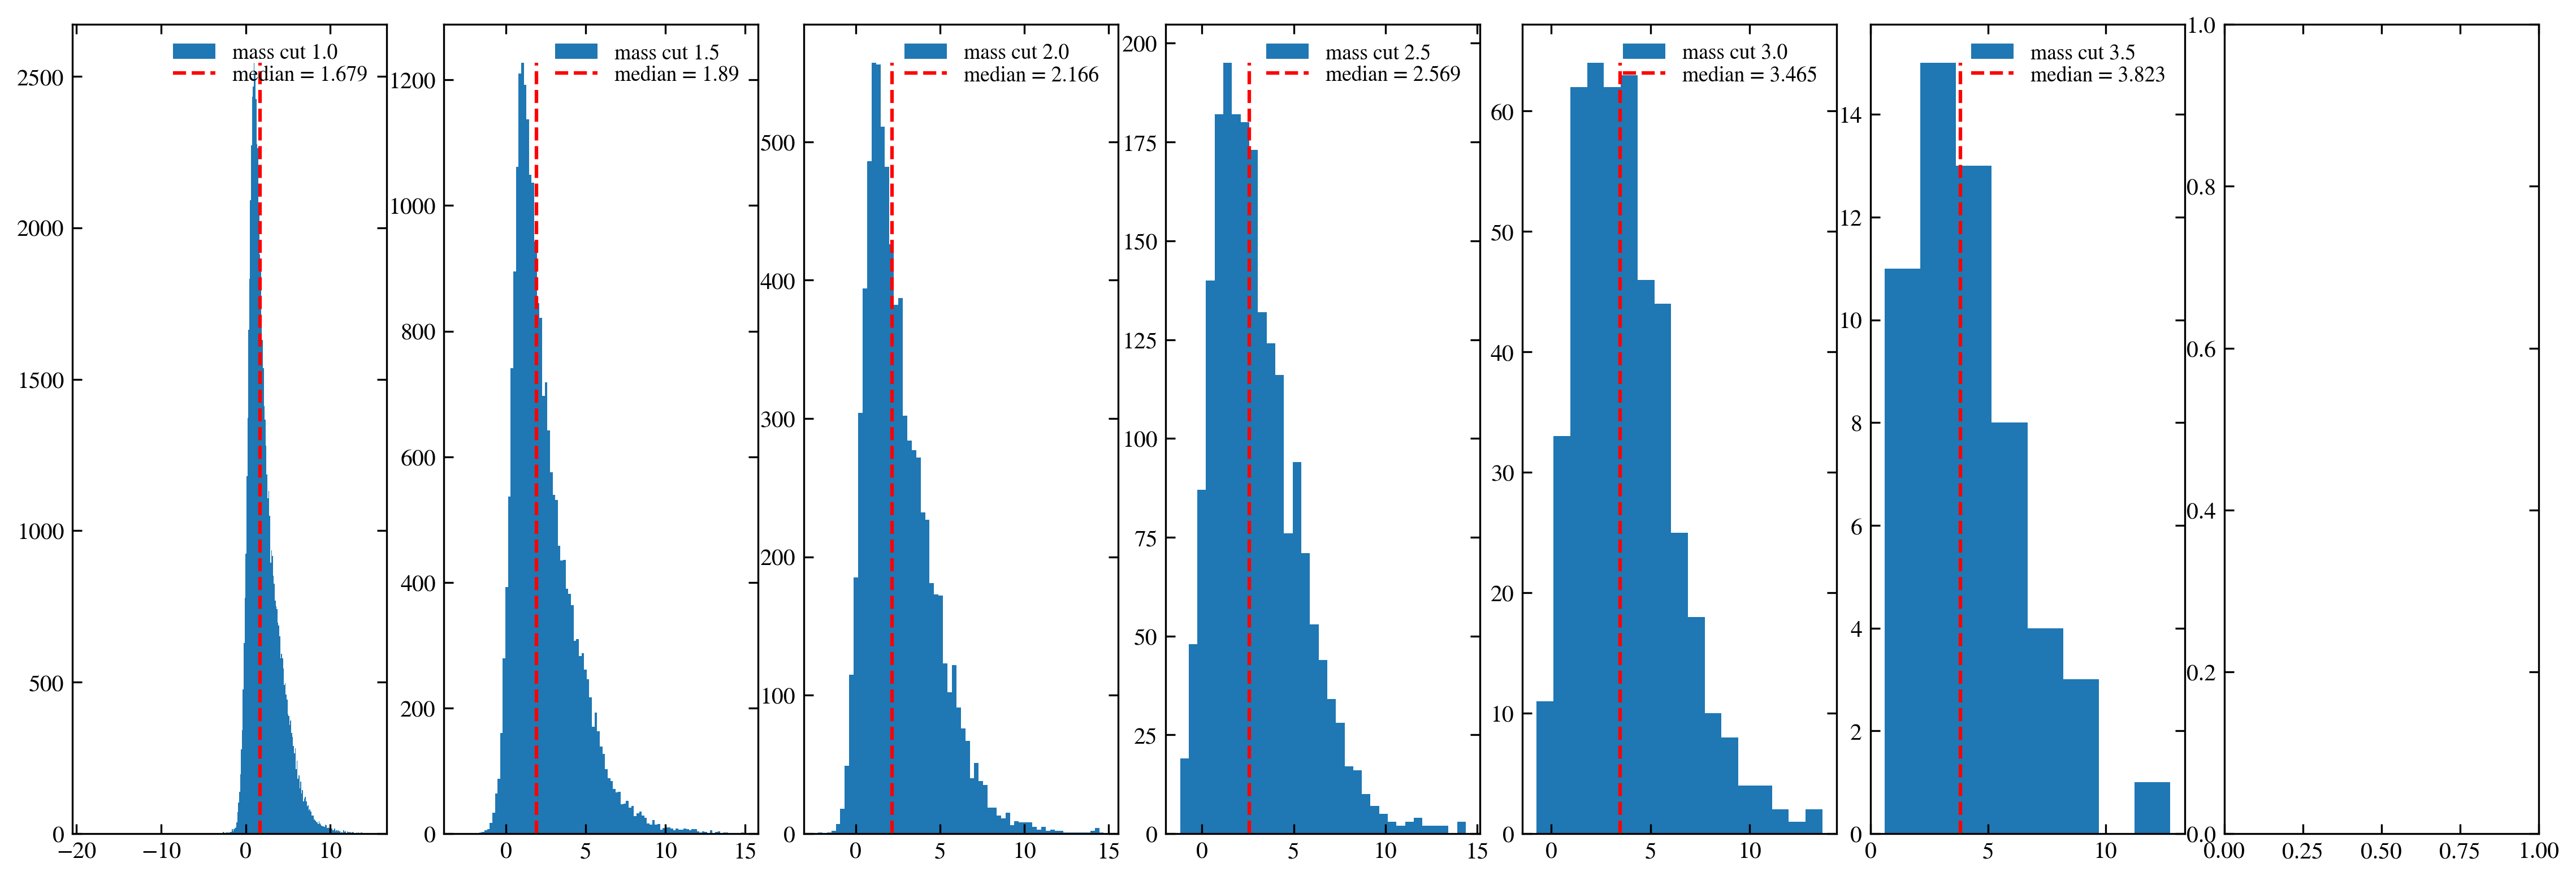

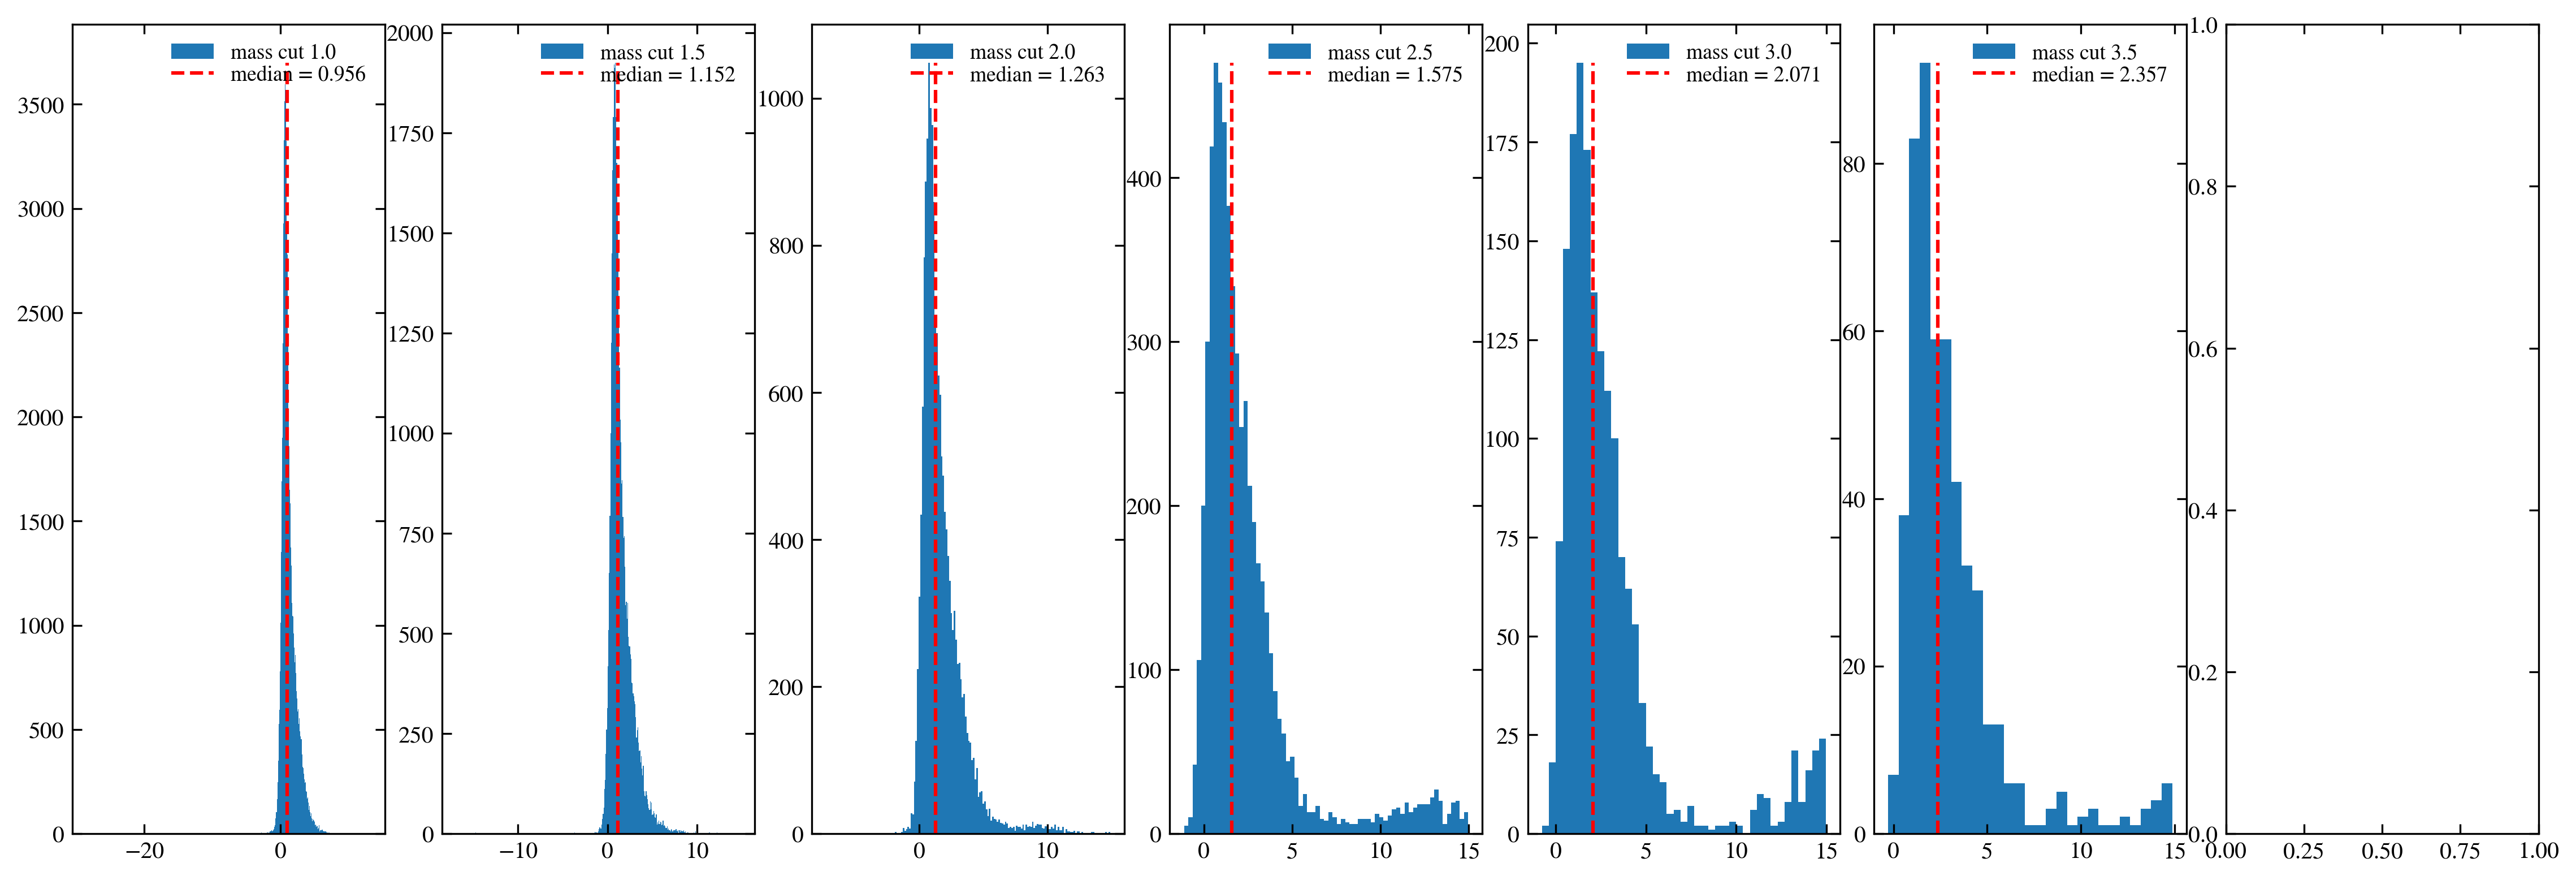

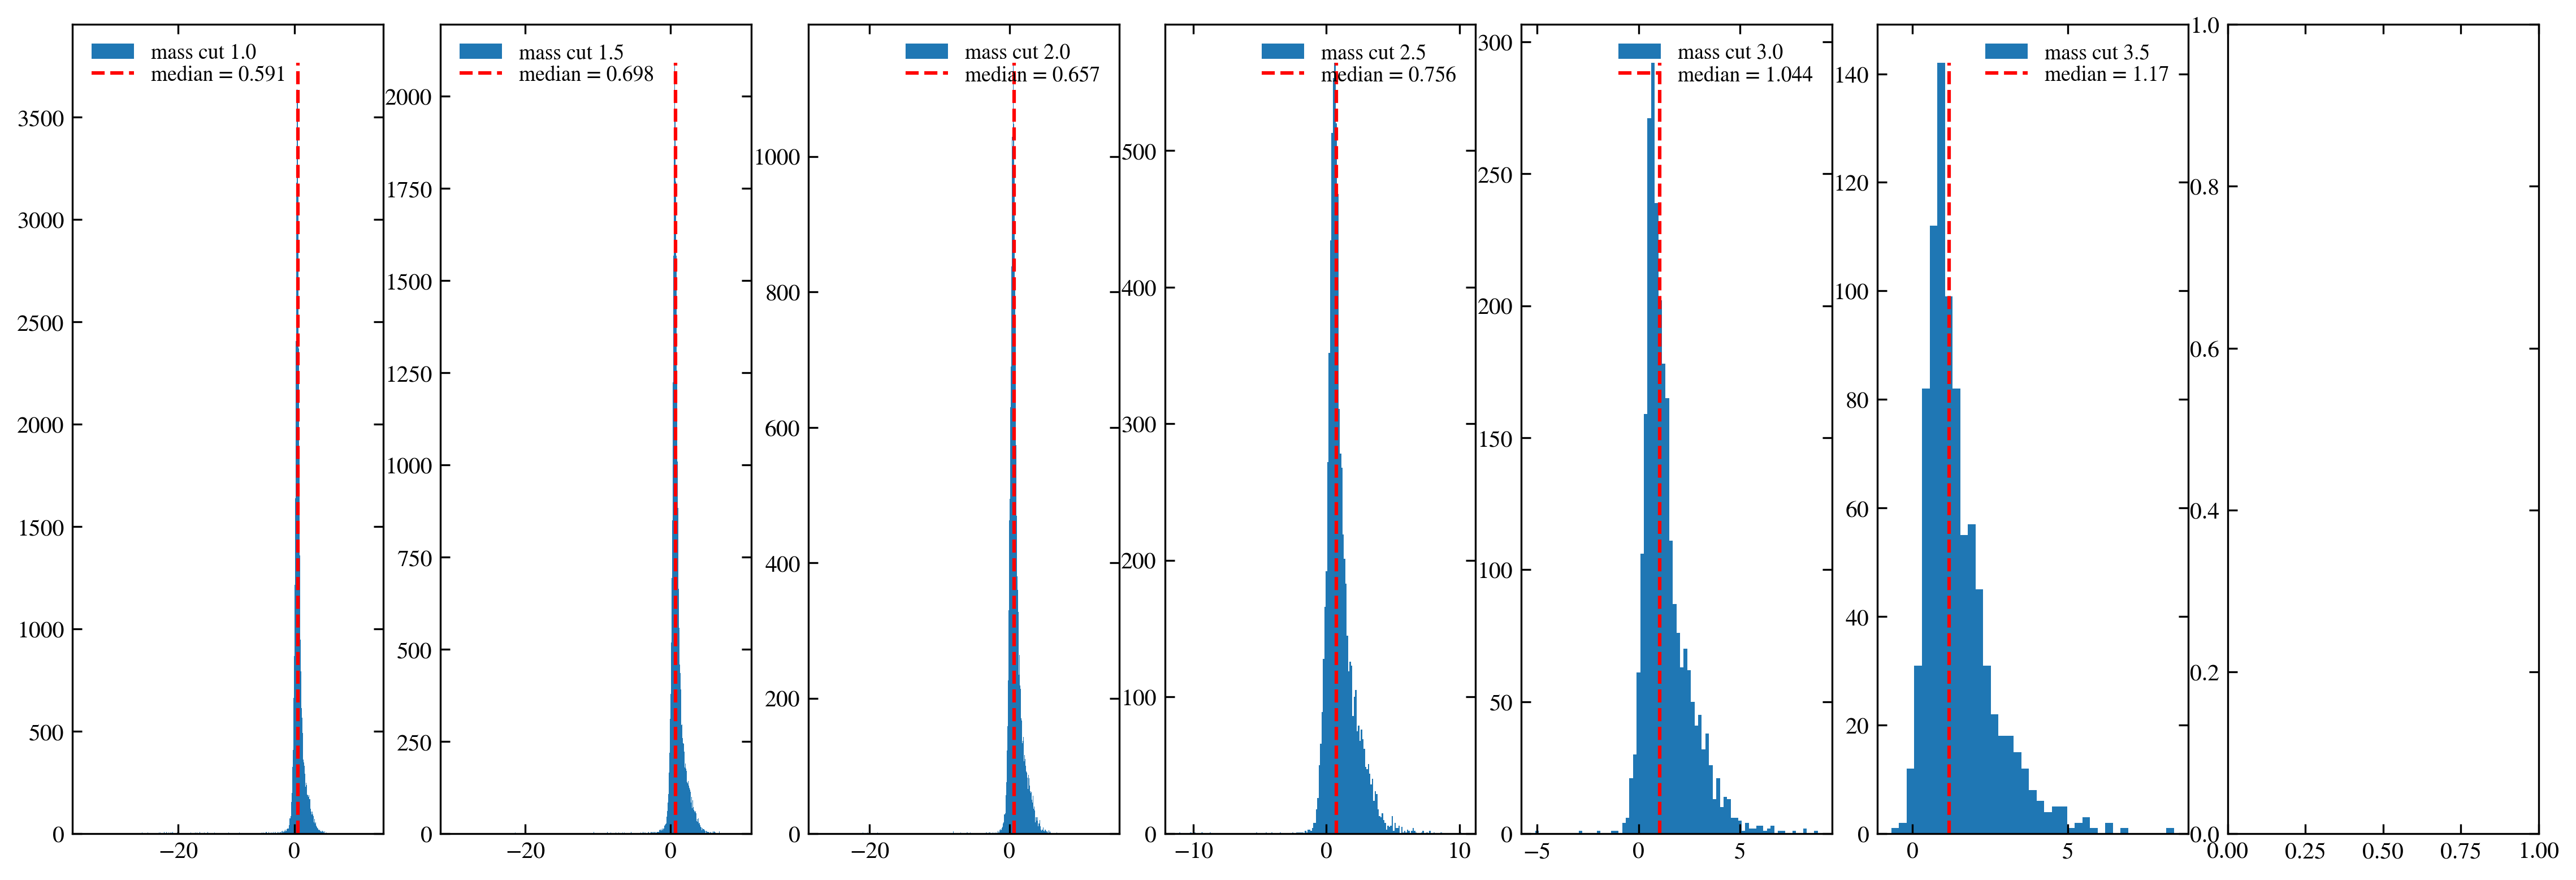

In [12]:
for isnap in range(len(snap_list)):
    
    if isnap != 0: # Assign the accretion rate between snapshots s1 and s2 to the later s2
        fig, axes = plt.subplots(1, num_cuts, figsize=(15, 5))
        
        mass = mass_df.iloc[isnap, :]
        rate = accretion_df.iloc[isnap, :]
        
        # Drop inf and nan
        rate = rate.replace([np.inf, -np.inf], np.nan)
        valid_mask = ~np.isnan(rate)
        rate, mass = rate[valid_mask], mass[valid_mask]

        for icut, cut in enumerate(mass_cuts[:-1]): 
            # Assign the accretion rate between mass_cut m1 and m2 to the former m1
            # Get the mass bin
            mass_mask = (mass >= 10**mass_cuts[icut]) & (mass < 10**mass_cuts[icut+1])
            rate_cut = rate[mass_mask]
            
            if rate_cut.empty:
                pass
            else:
                # At later snaps, two normal distri of accret rates appear per mass cut per snap,
                # Can check the histogram per mass cut per snap. 
                # Here we just simply remove the higher accret rates distri.
                rate_mask = (rate_cut <= 15)
                rate_cut  = rate_cut[rate_mask]
                
                median     = np.median(rate_cut)
                std        = np.std(rate_cut)
                low_bound  = np.percentile(rate_cut, 16)
                high_bound = np.percentile(rate_cut, 84)
                
                # Plot the histogram
                hist = axes[icut].hist(rate_cut, label=f'mass cut {mass_cuts[icut]}')[0]
                axes[icut].plot([median, median], [0, max(hist)], linestyle='dashed', color='red', 
                                label=f'median = {np.round(median, 3)}')
                axes[icut].legend(loc='best')
                
                median_array[isnap, icut] = median
                std_array[isnap, icut]    = std
                lowp_array[isnap, icut]   = low_bound
                highp_array[isnap, icut]  = high_bound

In [14]:
for icut, cut in enumerate(mass_cuts[:-1]): 
    print(lowp_array[:, icut])
    print(median_array[:, icut])
    print(highp_array[:, icut])
    print('')

[0.         4.19699911 1.65325361 0.5734202  0.38683916 0.19061528]
[0.         6.03717671 3.31537199 1.67896973 0.95615623 0.59099234]
[0.         8.5882843  5.67452744 3.95827645 2.23157627 1.25858632]

[0.         4.22234427 1.84939445 0.70517783 0.5178495  0.30787523]
[0.         6.09535137 3.59836749 1.8900734  1.152152   0.69781503]
[0.         8.53655772 5.8415028  4.22847184 2.6096457  1.5146376 ]

[0.         5.05084362 2.36899492 0.78589002 0.46885821 0.17602331]
[0.         5.78974444 4.16035579 2.16637544 1.26306007 0.65740095]
[0.         6.53074282 6.49343664 4.62378362 2.9532834  1.58226885]

[0.         0.         2.69348975 0.79209442 0.46884174 0.21246263]
[0.         0.         4.61961142 2.56902061 1.57515845 0.75621662]
[0.         0.         6.83134616 5.28941108 3.78130832 1.96607003]

[0.         0.         3.70260095 1.43734758 0.83554072 0.45581435]
[0.         0.         5.59501658 3.46484242 2.07090082 1.04443902]
[0.         0.         7.65280267 6.06891286

In [17]:
import h5py
import illustris_python as il
# Load redshift
redshifts = []
for snap in snap_list:
    with h5py.File(il.snapshot.snapPath(basePath, int(snap[5:])), 'r') as f:
        header = dict(f['Header'].attrs.items())
        scale_factor = header['Time']
        z = 1 / scale_factor - 1
        redshifts.append(z)
redshifts = np.array(redshifts)

Text(0.5, 1.0, 'TNG300')

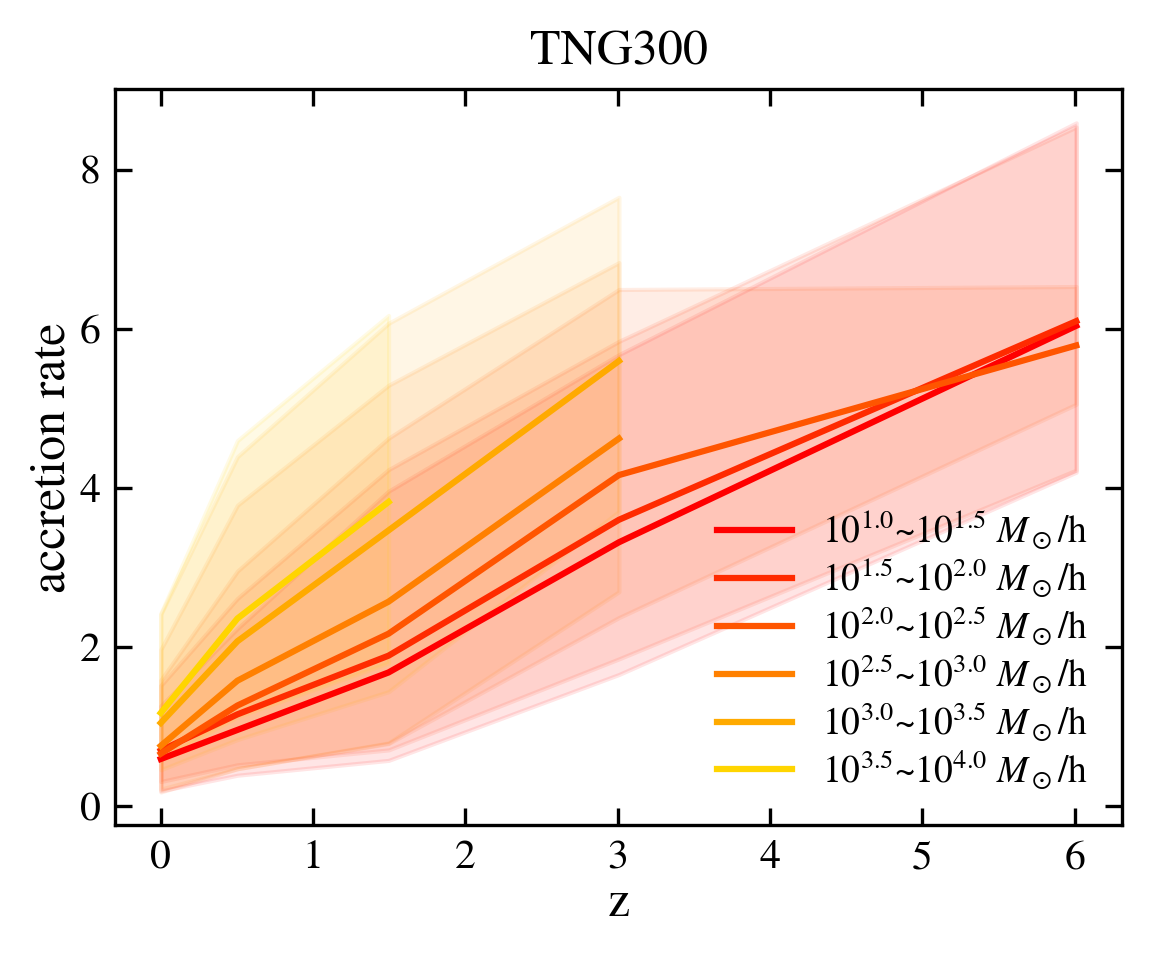

In [19]:
fig, ax = plt.subplots(1, 1,)
cmap = plt.get_cmap('autumn', len(mass_cuts))
for icut in range(len(mass_cuts)-1):
    
    mask = median_array[:, icut] != 0 # Remove zero terms
    ax.plot(redshifts[mask], median_array[mask, icut], color=cmap(icut/len(mass_cuts)), 
             label=r'$10^{%.1f}$'%mass_cuts[icut]+'~'
                  +r'$10^{%.1f}$ '%mass_cuts[icut+1]+'$M_\\odot$/h')
    plt.fill_between(redshifts[mask], lowp_array[mask, icut], highp_array[mask, icut], 
                     alpha=0.1, color=cmap(icut/len(mass_cuts)))
ax.set_xlabel('z')
ax.set_ylabel('accretion rate')
ax.legend(loc='best')
ax.set_title(f'TNG300{DM}')

In [20]:
for icut, cut in enumerate(mass_cuts[:-1]): 
    print(std_array[:, icut])

[0.         2.24762882 2.12579582 1.87668167 1.16543507 2.57826338]
[0.         2.34577636 2.12667054 1.94468834 1.3098808  1.75409941]
[0.         0.87770429 2.22271342 2.04841236 1.69940791 1.22527561]
[0.         0.         2.14107648 2.3515023  2.94927678 1.11292706]
[0.         0.         2.095294   2.46602456 3.35091656 1.15695687]
[0.         0.         0.         2.44150895 2.73442079 1.09682183]


Text(0.5, 1.0, 'TNG300')

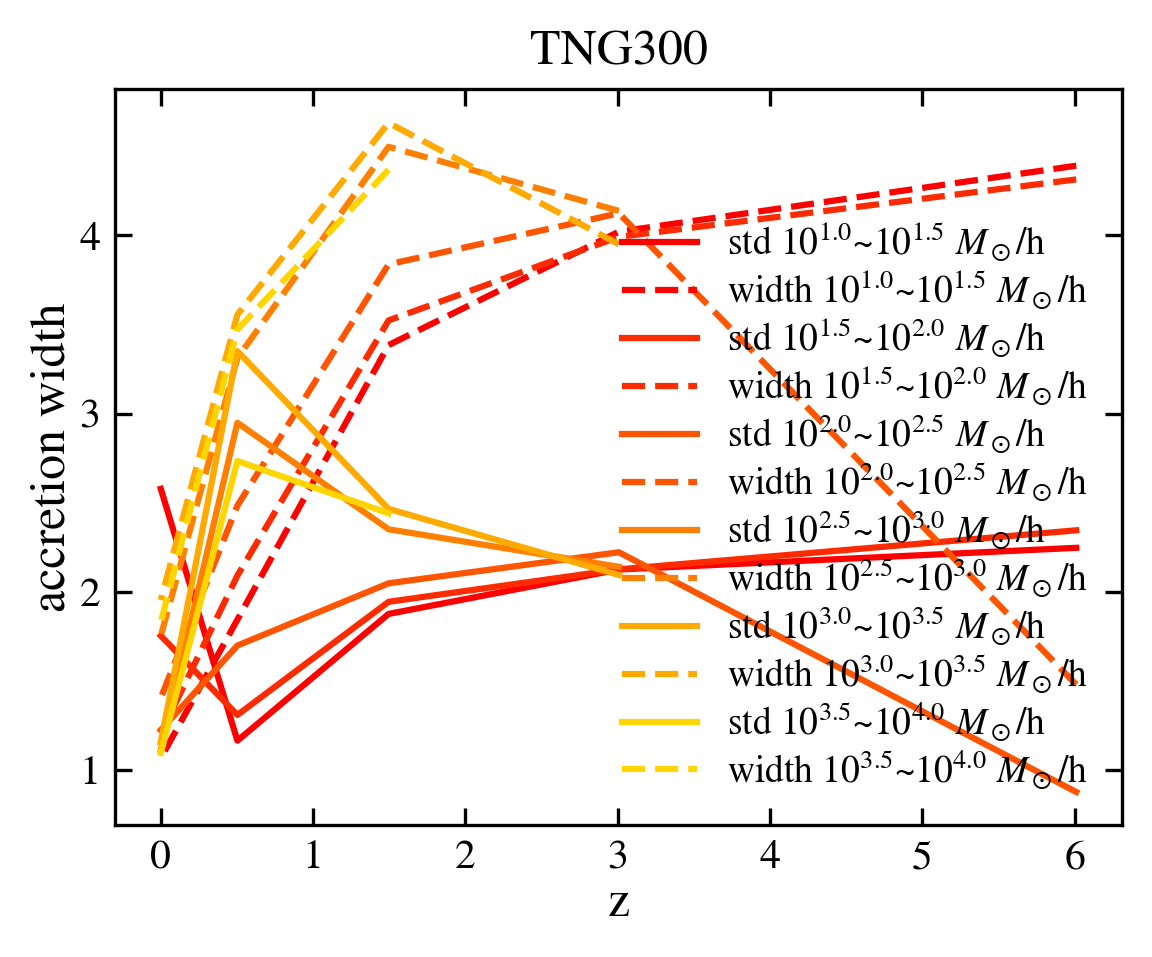

In [23]:
fig, ax = plt.subplots(1, 1,)
cmap = plt.get_cmap('autumn', len(mass_cuts))
for icut in range(len(mass_cuts)-1):
    
    mask = median_array[:, icut] != 0 # Remove zero terms

    ax.plot(redshifts[mask], std_array[mask, icut], color=cmap(icut/len(mass_cuts)), 
             label='std '+r'$10^{%.1f}$'%mass_cuts[icut]+'~'
                  +r'$10^{%.1f}$ '%mass_cuts[icut+1]+'$M_\\odot$/h')
    ax.plot(redshifts[mask], highp_array[mask, icut]-lowp_array[mask, icut], 
             color=cmap(icut/len(mass_cuts)), 
             label='width '+r'$10^{%.1f}$'%mass_cuts[icut]+'~'
                  +r'$10^{%.1f}$ '%mass_cuts[icut+1]+'$M_\\odot$/h', linestyle='--')
ax.set_xlabel('z')
ax.set_ylabel('accretion width')
ax.legend(loc='best')
ax.set_title(f'TNG300{DM}')